# Email Phishing Random Forest

This notebook trains one RandomForest classifier for email phishing detection. The model contract mirrors the backend request schema:

```python
class EmailRequest(BaseModel):
    subject: str
    body: str
    sender: EmailStr
    raw_headers: Optional[str] = None
```

The ONNX model accepts a numeric feature vector extracted from those fields. The pickle export stores the trained model and feature contract.

In [5]:
from pathlib import Path
import json
import re
from email import policy
from email.parser import Parser
from email.utils import parseaddr

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    RocCurveDisplay,
)
from sklearn.model_selection import train_test_split

RANDOM_STATE = 42
NOTEBOOK_DIR = Path('/home/azimeh/Desktop/Code/PHISHIELD/ml/notebooks')
PROJECT_ROOT = NOTEBOOK_DIR.parent
DATA_PATH = NOTEBOOK_DIR / "phishing_email.csv"
MODELS_DIR = PROJECT_ROOT / "models"
OUTPUTS_DIR = MODELS_DIR / "outputs"

print(f"Data path: {DATA_PATH}")
print(f"Models dir: {MODELS_DIR}")

Data path: /home/azimeh/Desktop/Code/PHISHIELD/ml/notebooks/phishing_email.csv
Models dir: /home/azimeh/Desktop/Code/PHISHIELD/ml/models


In [6]:
df = pd.read_csv(DATA_PATH)
print(f"Dataset shape: {df.shape}")
print(df.head())

required = {"text_combined", "label"}
missing = required - set(df.columns)
if missing:
    raise ValueError(f"Missing required columns: {sorted(missing)}")

# Normalize labels to backend convention: 0 = legitimate, 1 = phishing.
df = df[["text_combined", "label"]].dropna(subset=["text_combined", "label"]).copy()
df["label"] = df["label"].astype(int)

print("Class distribution:")
print(df["label"].value_counts().rename(index={0: "legitimate", 1: "phishing"}))

Dataset shape: (82486, 2)
                                       text_combined  label
0  hpl nom may 25 2001 see attached file hplno 52...      0
1  nom actual vols 24 th forwarded sabrae zajac h...      0
2  enron actuals march 30 april 1 201 estimated a...      0
3  hpl nom may 30 2001 see attached file hplno 53...      0
4  hpl nom june 1 2001 see attached file hplno 60...      0
Class distribution:
label
phishing      42891
legitimate    39595
Name: count, dtype: int64


In [7]:
def to_email_request_frame(data: pd.DataFrame) -> pd.DataFrame:
    """Create backend-shaped inputs from this dataset.

    The source CSV only contains a combined text field, so subject/body are derived
    from it. Real backend inference should pass the actual subject, body, sender,
    and raw_headers values.
    """
    text = data["text_combined"].fillna("").astype(str)
    return pd.DataFrame({
        "subject": text.str.slice(0, 120),
        "body": text,
        "sender": "unknown@example.com",
        "raw_headers": "",
    })

email_df = to_email_request_frame(df)
y = df["label"].copy()
print(email_df.head())

                                             subject  \
0  hpl nom may 25 2001 see attached file hplno 52...   
1  nom actual vols 24 th forwarded sabrae zajac h...   
2  enron actuals march 30 april 1 201 estimated a...   
3  hpl nom may 30 2001 see attached file hplno 53...   
4  hpl nom june 1 2001 see attached file hplno 60...   

                                                body               sender  \
0  hpl nom may 25 2001 see attached file hplno 52...  unknown@example.com   
1  nom actual vols 24 th forwarded sabrae zajac h...  unknown@example.com   
2  enron actuals march 30 april 1 201 estimated a...  unknown@example.com   
3  hpl nom may 30 2001 see attached file hplno 53...  unknown@example.com   
4  hpl nom june 1 2001 see attached file hplno 60...  unknown@example.com   

  raw_headers  
0              
1              
2              
3              
4              


In [8]:
SUSPICIOUS_WORDS = {
    "urgent", "verify", "verification", "password", "account", "login",
    "signin", "click", "confirm", "suspend", "suspended", "limited",
    "update", "security", "alert", "bank", "wallet", "invoice", "payment",
    "claim", "reward", "winner", "free", "gift", "bonus", "prize",
}

MONEY_WORDS = {"payment", "invoice", "wire", "transfer", "bank", "account", "refund", "deposit", "bitcoin", "crypto"}
BRAND_WORDS = {"paypal", "google", "microsoft", "apple", "facebook", "instagram", "netflix", "amazon", "binance", "mtn", "airtel", "opay"}
URL_RE = re.compile(r"https?://|www\.", re.IGNORECASE)
EMAIL_RE = re.compile(r"[a-zA-Z0-9_.+-]+@[a-zA-Z0-9-]+\.[a-zA-Z0-9-.]+")

FEATURE_NAMES = [
    "subject_len", "body_len", "total_len", "word_count", "unique_word_ratio",
    "uppercase_ratio", "digit_ratio", "punctuation_count", "exclamation_count",
    "question_count", "url_count", "email_count", "suspicious_word_count",
    "money_word_count", "brand_word_count", "has_html", "sender_domain_len",
    "sender_is_free_mail", "spf_fail", "dkim_fail", "dmarc_fail",
    "auth_missing", "reply_to_mismatch", "return_path_mismatch",
]

FREE_MAIL_DOMAINS = {"gmail.com", "yahoo.com", "outlook.com", "hotmail.com", "aol.com", "icloud.com", "proton.me", "protonmail.com"}

def _domain_from_email(value: str) -> str:
    _, address = parseaddr(str(value or ""))
    if "@" not in address:
        return ""
    return address.rsplit("@", 1)[-1].lower().strip(">")

def _header_value(raw_headers: str, name: str) -> str:
    if not raw_headers:
        return ""
    try:
        message = Parser(policy=policy.default).parsestr(raw_headers)
        return str(message.get(name, ""))
    except Exception:
        return ""

def extract_email_features(requests: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for _, row in requests.fillna("").iterrows():
        subject = str(row.get("subject", ""))
        body = str(row.get("body", ""))
        sender = str(row.get("sender", ""))
        raw_headers = str(row.get("raw_headers", ""))
        text = f"{subject} {body}"
        lower_text = text.lower()
        words = re.findall(r"[a-zA-Z0-9_]+", lower_text)
        chars = list(text)
        total_len = len(text)
        sender_domain = _domain_from_email(sender)
        reply_to_domain = _domain_from_email(_header_value(raw_headers, "Reply-To"))
        return_path_domain = _domain_from_email(_header_value(raw_headers, "Return-Path"))
        headers_lower = raw_headers.lower()

        rows.append({
            "subject_len": len(subject),
            "body_len": len(body),
            "total_len": total_len,
            "word_count": len(words),
            "unique_word_ratio": len(set(words)) / max(len(words), 1),
            "uppercase_ratio": sum(c.isupper() for c in chars) / max(total_len, 1),
            "digit_ratio": sum(c.isdigit() for c in chars) / max(total_len, 1),
            "punctuation_count": sum(not c.isalnum() and not c.isspace() for c in chars),
            "exclamation_count": text.count("!"),
            "question_count": text.count("?"),
            "url_count": len(URL_RE.findall(text)),
            "email_count": len(EMAIL_RE.findall(text)),
            "suspicious_word_count": sum(word in SUSPICIOUS_WORDS for word in words),
            "money_word_count": sum(word in MONEY_WORDS for word in words),
            "brand_word_count": sum(word in BRAND_WORDS for word in words),
            "has_html": int("<html" in lower_text or "</" in lower_text or "href=" in lower_text),
            "sender_domain_len": len(sender_domain),
            "sender_is_free_mail": int(sender_domain in FREE_MAIL_DOMAINS),
            "spf_fail": int("spf=fail" in headers_lower or "spf=softfail" in headers_lower),
            "dkim_fail": int("dkim=fail" in headers_lower or "dkim=none" in headers_lower),
            "dmarc_fail": int("dmarc=fail" in headers_lower or "dmarc=none" in headers_lower),
            "auth_missing": int(bool(raw_headers.strip()) and "authentication-results" not in headers_lower),
            "reply_to_mismatch": int(bool(reply_to_domain and sender_domain and reply_to_domain != sender_domain)),
            "return_path_mismatch": int(bool(return_path_domain and sender_domain and return_path_domain != sender_domain)),
        })
    return pd.DataFrame(rows, columns=FEATURE_NAMES).astype(np.float32)

X = extract_email_features(email_df)
print(X.head())
print(f"Feature matrix shape: {X.shape}")

   subject_len  body_len  total_len  word_count  unique_word_ratio  \
0         65.0      65.0      131.0        28.0           0.392857   
1        120.0    1071.0     1192.0       231.0           0.432900   
2        120.0     148.0      269.0        52.0           0.346154   
3         65.0      65.0      131.0        28.0           0.392857   
4         65.0      65.0      131.0        28.0           0.392857   

   uppercase_ratio  digit_ratio  punctuation_count  exclamation_count  \
0              0.0     0.183206                0.0                0.0   
1              0.0     0.125000                0.0                0.0   
2              0.0     0.208178                0.0                0.0   
3              0.0     0.183206                0.0                0.0   
4              0.0     0.167939                0.0                0.0   

   question_count  ...  brand_word_count  has_html  sender_domain_len  \
0             0.0  ...               0.0       0.0               11

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f"Train shape: {X_train.shape}")
print(f"Test shape:  {X_test.shape}")
print("Train distribution:")
print(y_train.value_counts().rename(index={0: "legitimate", 1: "phishing"}))
print("Test distribution:")
print(y_test.value_counts().rename(index={0: "legitimate", 1: "phishing"}))

Train shape: (65988, 24)
Test shape:  (16498, 24)
Train distribution:
label
phishing      34312
legitimate    31676
Name: count, dtype: int64
Test distribution:
label
phishing      8579
legitimate    7919
Name: count, dtype: int64


In [10]:
model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=2,
    class_weight="balanced_subsample",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

metrics = {
    "accuracy": accuracy_score(y_test, y_pred),
    "precision": precision_score(y_test, y_pred),
    "recall": recall_score(y_test, y_pred),
    "f1": f1_score(y_test, y_pred),
    "roc_auc": roc_auc_score(y_test, y_proba),
}

print("Evaluation metrics")
for key, value in metrics.items():
    print(f"{key:>10}: {value:.4f}")

print("\nClassification report")
print(classification_report(y_test, y_pred, target_names=["legitimate", "phishing"]))

Evaluation metrics
  accuracy: 0.8760
 precision: 0.8967
    recall: 0.8607
        f1: 0.8783
   roc_auc: 0.9474

Classification report
              precision    recall  f1-score   support

  legitimate       0.86      0.89      0.87      7919
    phishing       0.90      0.86      0.88      8579

    accuracy                           0.88     16498
   macro avg       0.88      0.88      0.88     16498
weighted avg       0.88      0.88      0.88     16498



Saved confusion matrix to /home/azimeh/Desktop/Code/PHISHIELD/ml/models/outputs/email_confusion_matrix.png


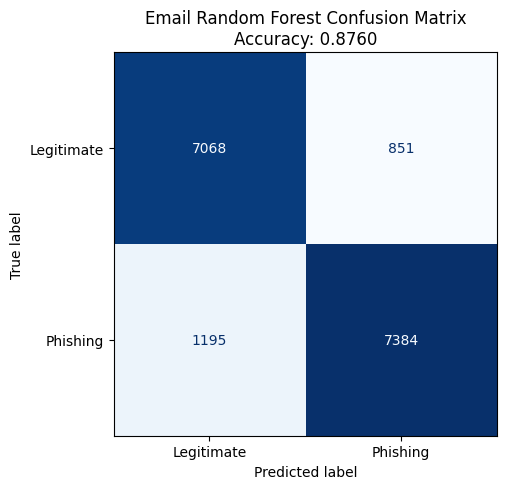

In [11]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Legitimate", "Phishing"])
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap="Blues", values_format="d", colorbar=False)
ax.set_title(f"Email Random Forest Confusion Matrix\nAccuracy: {metrics['accuracy']:.4f}")
plt.tight_layout()
cm_path = OUTPUTS_DIR / "email_confusion_matrix.png"
plt.savefig(cm_path, dpi=300, bbox_inches="tight")
print(f"Saved confusion matrix to {cm_path}")
plt.show()

Saved ROC curve to /home/azimeh/Desktop/Code/PHISHIELD/ml/models/outputs/email_roc_curve.png


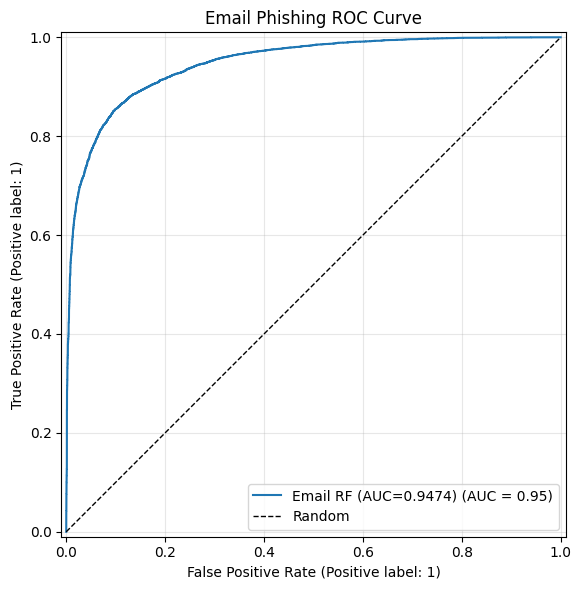

In [12]:
fig, ax = plt.subplots(figsize=(7, 6))
RocCurveDisplay.from_predictions(y_test, y_proba, ax=ax, name=f"Email RF (AUC={metrics['roc_auc']:.4f})")
ax.plot([0, 1], [0, 1], "k--", linewidth=1, label="Random")
ax.set_title("Email Phishing ROC Curve")
ax.grid(alpha=0.3)
ax.legend(loc="lower right")
plt.tight_layout()
roc_path = OUTPUTS_DIR / "email_roc_curve.png"
plt.savefig(roc_path, dpi=300, bbox_inches="tight")
print(f"Saved ROC curve to {roc_path}")
plt.show()

Saved feature importance to /home/azimeh/Desktop/Code/PHISHIELD/ml/models/outputs/email_feature_importance.png


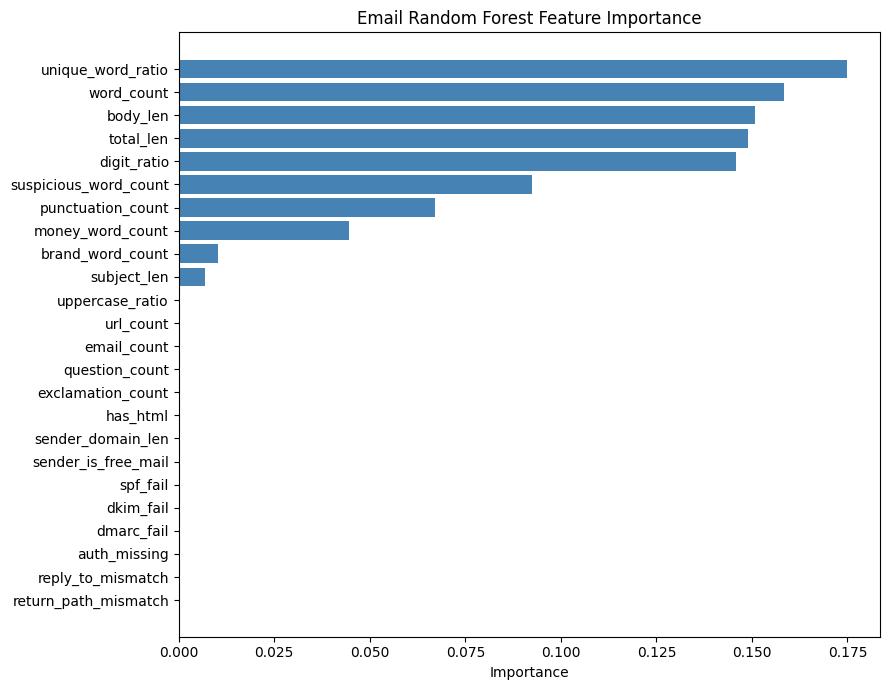

,feature,importance
4,unique_word_ratio,0.174778
3,word_count,0.158453
1,body_len,0.150766
2,total_len,0.148990
6,digit_ratio,0.145957
12,suspicious_word_count,0.092434
7,punctuation_count,0.067152
13,money_word_count,0.044507
14,brand_word_count,0.010179
0,subject_len,0.006782


In [13]:
importance_df = pd.DataFrame({
    "feature": FEATURE_NAMES,
    "importance": model.feature_importances_,
}).sort_values("importance", ascending=False)

fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(importance_df["feature"], importance_df["importance"], color="steelblue")
ax.invert_yaxis()
ax.set_xlabel("Importance")
ax.set_title("Email Random Forest Feature Importance")
plt.tight_layout()
importance_path = OUTPUTS_DIR / "email_feature_importance.png"
plt.savefig(importance_path, dpi=300, bbox_inches="tight")
print(f"Saved feature importance to {importance_path}")
plt.show()

importance_df.head(15)

In [14]:
def predict_email_phishing(subject: str, body: str, sender: str, raw_headers: str | None = None) -> dict:
    request_df = pd.DataFrame([{
        "subject": subject,
        "body": body,
        "sender": sender,
        "raw_headers": raw_headers or "",
    }])
    features = extract_email_features(request_df)
    score = float(model.predict_proba(features)[:, 1][0])
    return {
        "phishing_probability": score,
        "risk_score": round(score * 100),
        "prediction": "phishing" if score >= 0.5 else "legitimate",
    }

example = predict_email_phishing(
    subject="Urgent: verify your account",
    body="Click the link now to confirm your password and avoid suspension: http://example.bad/login",
    sender="security@example.bad",
    raw_headers="Authentication-Results: mx.example; spf=fail; dkim=none; dmarc=fail",
)
example

{'phishing_probability': 0.6820285265400418,
 'risk_score': 68,
 'prediction': 'phishing'}

In [15]:
pkl_path = MODELS_DIR / "email_rf_model.pkl"
bundle = {
    "model": model,
    "feature_names": FEATURE_NAMES,
    "metrics": metrics,
    "label_contract": {0: "legitimate", 1: "phishing"},
    "input_schema": {
        "subject": "str",
        "body": "str",
        "sender": "EmailStr",
        "raw_headers": "Optional[str]",
    },
}
joblib.dump(bundle, pkl_path)
print(f"Saved pickle bundle to {pkl_path}")
print(f"Size: {pkl_path.stat().st_size / 1024:.2f} KB")

Saved pickle bundle to /home/azimeh/Desktop/Code/PHISHIELD/ml/models/email_rf_model.pkl
Size: 247616.02 KB


In [16]:
onnx_path = MODELS_DIR / "email_rf_model.onnx"
try:
    from skl2onnx import convert_sklearn #type: ignore
    from skl2onnx.common.data_types import FloatTensorType #type: ignore

    initial_type = [("float_input", FloatTensorType([None, len(FEATURE_NAMES)]))]
    onnx_model = convert_sklearn(
        model,
        initial_types=initial_type,
        target_opset=12,
        options={id(model): {"zipmap": False}},
    )
    onnx_path.write_bytes(onnx_model.SerializeToString())
    print(f"Saved ONNX model to {onnx_path}")
    print(f"Size: {onnx_path.stat().st_size / 1024:.2f} KB")
except Exception as exc:
    print(f"ONNX export failed: {exc}")
    print("The pickle model is still exported. Install/update skl2onnx and rerun this cell to create ONNX.")

Saved ONNX model to /home/azimeh/Desktop/Code/PHISHIELD/ml/models/email_rf_model.onnx
Size: 123253.17 KB


In [17]:
contract_path = MODELS_DIR / "email_feature_contract.json"
contract = {
    "model": "RandomForestClassifier",
    "onnx_input": {
        "name": "float_input",
        "shape": [None, len(FEATURE_NAMES)],
        "feature_order": FEATURE_NAMES,
    },
    "backend_input_schema": {
        "subject": "str",
        "body": "str",
        "sender": "EmailStr",
        "raw_headers": "Optional[str]",
    },
    "output": {
        "probability_column": 1,
        "class_0": "legitimate",
        "class_1": "phishing",
    },
    "metrics": metrics,
}
contract_path.write_text(json.dumps(contract, indent=2))
print(f"Saved feature contract to {contract_path}")

Saved feature contract to /home/azimeh/Desktop/Code/PHISHIELD/ml/models/email_feature_contract.json
